_Copyright (C) 2024 Jagger Alexander_

_This program is free software: you can redistribute it and/or modify it as published._

_This program is distributed in the hope that it will be informative, but without any warranty; without even the implied warranty of merchantability or fitness for a particular purpose._

### Process ERA5 data for ML-based heat wave prediction

1. Import necessary packages
2. Import downloaded geopotential height data 
3. Create 500mb example before processing data
4. Process geopotential data and output for prediction

In [9]:
#1. Import necessary packages
#---

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [5]:
#2. Import downloaded geopotential height data 
#---

# Open the dataset
geopotential_daily = xr.open_dataset(r"C:\Users\17753\Documents\AustinClim\ERA5Geopotential\geopotential_daily.nc")
print(geopotential_daily.head())


<xarray.Dataset> Size: 2kB
Dimensions:         (pressure_level: 3, latitude: 5, longitude: 5, valid_time: 5)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 24B 850.0 500.0 250.0
  * latitude        (latitude) float64 40B 55.0 54.75 54.5 54.25 54.0
  * longitude       (longitude) float64 40B -135.0 -134.8 -134.5 -134.2 -134.0
  * valid_time      (valid_time) datetime64[ns] 40B 2013-01-01 ... 2013-01-05
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 2kB ...


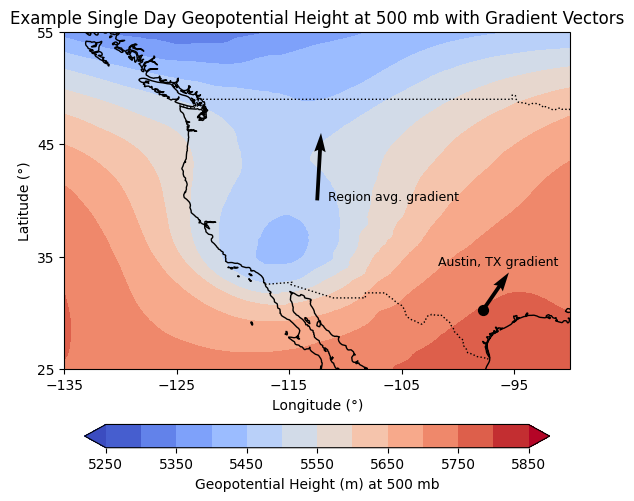

In [7]:
#3. Create 500mb example before processing data
#---

# Select the 500 mb pressure level and a specific time step (time step adjustable)
geopotential_500mb_daily = geopotential_daily.sel(
    pressure_level=500.0,
    latitude=slice(55.0, 25.0),   # Latitude range (reverse order for descending)
    longitude=slice(-135.0, -90.0)  # Longitude range
).isel(valid_time=282)

# Extract the geopotential height variable (assuming it's named 'z')
geopotential_2d = geopotential_500mb_daily['z'].values/10  # Shape (latitude, longitude)

# Approximate grid spacing (in meters)
latitudes = geopotential_500mb_daily['latitude'].values
longitudes = geopotential_500mb_daily['longitude'].values

# Calculate dx and dy for gradient calculations
dx = 111000 * np.cos(np.radians(latitudes))  # Adjust dx based on latitude
dy = 111000  # Constant dy value in meters

# Initialize arrays for the gradients
dz_dx = np.zeros(geopotential_2d.shape)
dz_dy = np.zeros(geopotential_2d.shape)

# Calculate gradients manually
for i in range(geopotential_2d.shape[0]):
    for j in range(geopotential_2d.shape[1]):
        if j > 0 and j < geopotential_2d.shape[1] - 1:  # For interior points
            dz_dx[i, j] = (geopotential_2d[i, j + 1] - geopotential_2d[i, j - 1]) / (2 * dx[i])
        elif j == 0:  # Forward difference for the first column
            dz_dx[i, j] = (geopotential_2d[i, j + 1] - geopotential_2d[i, j]) / dx[i]
        elif j == geopotential_2d.shape[1] - 1:  # Backward difference for the last column
            dz_dx[i, j] = (geopotential_2d[i, j] - geopotential_2d[i, j - 1]) / dx[i]

for j in range(geopotential_2d.shape[1]):
    for i in range(geopotential_2d.shape[0]):
        if i > 0 and i < geopotential_2d.shape[0] - 1:  # For interior points
            dz_dy[i, j] = (geopotential_2d[i + 1, j] - geopotential_2d[i - 1, j]) / (2 * dy)
        elif i == 0:  # Forward difference for the first row
            dz_dy[i, j] = (geopotential_2d[i + 1, j] - geopotential_2d[i, j]) / dy
        elif i == geopotential_2d.shape[0] - 1:  # Backward difference for the last row
            dz_dy[i, j] = (geopotential_2d[i, j] - geopotential_2d[i - 1, j]) / dy

# Calculate average gradients over the region
avg_dz_dx = np.mean(dz_dx)
avg_dz_dy = np.mean(dz_dy)

# Extract the geopotential height for Austin, TX
austin_lat = 30.2672
austin_lon = -97.7431

# Find the closest indices for Austin's coordinates
lat_idx = (np.abs(latitudes - austin_lat)).argmin()
lon_idx = (np.abs(longitudes - austin_lon)).argmin()

# Get the geopotential height for Austin
z_austin = geopotential_2d[lat_idx, lon_idx]

# Prepare for plotting
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Add coastlines and borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

levels = np.arange(5250, 5851, 50)

# Plot the daily-averaged geopotential height at 500 mb
contour = ax.contourf(
    longitudes,
    latitudes,
    geopotential_2d,  # Use the 2D NumPy array for plotting
    levels=levels,
    cmap='coolwarm',
    extend='both'
)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.12,shrink=0.5)
cbar.set_label('Geopotential Height (m) at 500 mb')
cbar.set_ticks([5250,5350,5450,5550,5650,5750,5850])

# Plot the quiver for Austin's gradients (dz_x, dz_y at Austin)
ax.quiver(
    longitudes[lon_idx],
    latitudes[lat_idx],
    50000 * dz_dx[lat_idx, lon_idx],  # Scale gradients for better visibility
    50000 * dz_dy[lat_idx, lon_idx],
    color='black',  # Change arrow color to black
    scale=10,  # Adjust scaling factor as needed
    label='Austin, TX gradient',
    linestyle='--'  # Change line style to dashed
)

# Mark the endpoint for Austin's gradients
ax.scatter(
    longitudes[lon_idx],
    latitudes[lat_idx],
    color='black',  # Change color for visibility
    s=50,  # Size of the marker
    zorder=5  # Ensure the marker is on top
)

# Add text next to Austin
ax.text(
    longitudes[lon_idx] - 4,  # Adjust the position to the right of the arrow
    latitudes[lat_idx] + 4,
    'Austin, TX gradient',
    fontsize=9,
    color='black'
)

# Calculate the center of the map for average gradient quiver
center_lon = (longitudes.min() + longitudes.max()) / 2
center_lat = (latitudes.min() + latitudes.max()) / 2

# Plot the quiver for the average gradient at the center of the map
ax.quiver(
    center_lon,
    center_lat,
    50000 * avg_dz_dx,  # Scale average gradients for better visibility
    50000 * avg_dz_dy,
    color='black',  # Change average arrow color to black
    scale=10,  # Adjust scaling factor as needed
    label='Avg. gradient over region'
)

# Add text next to the average gradient
ax.text(
    center_lon + 1,  # Adjust the position to the right of the arrow
    center_lat,
    'Region avg. gradient',
    fontsize=9,
    color='black'
)

# Set title
ax.set_title('Example Single Day Geopotential Height at 500 mb with Gradient Vectors')

# Set latitude and longitude labels on the axes
ax.set_xticks(np.arange(-135, -90 + 1, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(25, 55 + 1, 10), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')

plt.show()

# Print the relevant data for inspection
#print(f"Austin Geopotential Height: {z_austin}")
#print(f"Austin dz/dx: {dz_dx[lat_idx, lon_idx]}")
#print(f"Austin dz/dy: {dz_dy[lat_idx, lon_idx]}")
#print(f"Avg dz/dx: {avg_dz_dx}")
#print(f"Avg dz/dy: {avg_dz_dy}")


In [12]:
#4. Process geopotential data and output for prediction
#---

# Function to process geopotential data for a given pressure level
def process_geopotential(pressure_level):
    # Select the specified pressure level
    geopotential_daily_level = geopotential_daily.sel(
        pressure_level=pressure_level,
        latitude=slice(55.0, 25.0),   # Latitude range
        longitude=slice(-135.0, -90.0)  # Longitude range
    )

    # Initialize a list to store results
    results = []

    # Constants
    R = 6371e3  # Earth's radius in meters
    dy = R * (np.pi / 180)  # Distance per degree of latitude
    dx = R * np.cos(np.radians(geopotential_daily_level['latitude'].values)) * (np.pi / 180)  # Distance per degree of longitude

    # Loop over each valid time
    for valid_time in geopotential_daily_level['valid_time']:
        geopotential_2d = geopotential_daily_level.sel(valid_time=valid_time)['z'].values  # Shape (latitude, longitude)

        # Calculate gradients of geopotential height over the entire region
        dz_dx = np.gradient(geopotential_2d, axis=1) / dx[:, np.newaxis]  # Gradient with respect to longitude
        dz_dy = np.gradient(geopotential_2d, axis=0) / dy  # Gradient with respect to latitude

        # Calculate average gradients over the region
        avg_dz_dx = np.mean(dz_dx)
        avg_dz_dy = np.mean(dz_dy)

        # Extract the geopotential height for Austin, TX
        austin_lat = 30.2672
        austin_lon = -97.7431

        # Find the closest indices for Austin's coordinates
        lat_idx = (np.abs(geopotential_daily_level['latitude'].values - austin_lat)).argmin()
        lon_idx = (np.abs(geopotential_daily_level['longitude'].values - austin_lon)).argmin()

        # Get the geopotential height for Austin
        z_austin = geopotential_2d[lat_idx, lon_idx]

        # Store results in the list
        results.append({
            'date': valid_time.values,
            f'dz_x_{pressure_level}': 10000 * dz_dx[lat_idx, lon_idx],
            f'dz_y_{pressure_level}': 10000 * dz_dy[lat_idx, lon_idx],
            f'z_aus_{pressure_level}': z_austin/10,
            f'avg_dz_x_{pressure_level}': 10000 * avg_dz_dx,
            f'avg_dz_y_{pressure_level}': 10000 * avg_dz_dy
        })

    # Create a DataFrame with the results
    results_df = pd.DataFrame(results)

    # Save the DataFrame to CSV
    #Edit output path
    results_df.to_csv(rf"C:\Users\17753\Documents\AustinClim\ERA5Geopotential\{pressure_level}mb_gradients.csv", index=False)

    # Display the DataFrame
    print(f"Gradients and averages for {pressure_level} mb saved to CSV:")
    print(results_df)

process_geopotential(500)

# Process geopotential data for 250 mb
process_geopotential(250)

# Process geopotential data for 850 mb
process_geopotential(850)


Gradients and averages for 500 mb saved to CSV:
           date  dz_x_500  dz_y_500    z_aus_500  avg_dz_x_500  avg_dz_y_500
0    2013-01-01  3.253374  5.114892  5620.372559     -1.451267      2.733554
1    2013-01-02  1.324123  4.041327  5604.184082     -0.668623      2.361472
2    2013-01-03  1.451005  4.530333  5591.580566     -0.627390      2.269035
3    2013-01-04  2.973584  4.884440  5619.926758     -0.418802      2.901130
4    2013-01-05  2.918277  5.842780  5634.163574      0.374085      2.959796
...         ...       ...       ...          ...           ...           ...
4012 2023-12-27 -0.055307  5.679778  5522.353027      0.757906      2.007187
4013 2023-12-28 -2.033359  4.429159  5517.310059      0.385829      2.024839
4014 2023-12-29 -4.479896  5.918660  5520.844727      0.405044      1.942984
4015 2023-12-30 -2.296882  2.251114  5592.611816     -0.003403      2.111379
4016 2023-12-31 -0.660435  2.816001  5632.159668     -0.225402      2.172291

[4017 rows x 6 columns]
Gra